In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from itertools import product
import pathlib as pth
import time
np.random.seed(42)

from minigrad.tensor import Tensor
from minigrad.nn import Sequential, Linear, Perceptron, Sigmoid, Softmax
from minigrad.nn.losses import categorical_cross_entropy
from minigrad.optim import GD, SGD

In [ ]:
# Specify the path to our CSV files

data_dir = pth.Path('/data') # Changed to absolute path
train_path = data_dir / 'fashion-mnist_train.csv'
test_path = data_dir / 'fashion-mnist_test.csv'

# 1. Load data via pandas
print("Loading data...")
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)



# In these CSVs, the first column is named 'label' (the correct answer from 0 to 9),
# and the remaining 784 columns are the image pixels (28x28).
# 2. Separate labels (y) from features/pixels (X)

y_train_raw = df_train['label'].values
X_train_raw = df_train.drop('label', axis=1).values

y_test_raw = df_test['label'].values
X_test_raw = df_test.drop('label', axis=1).values



# 3. Normalization (Task point 2)
# Pixels have values from 0 to 255. Neural networks struggle with such large numbers.
# Divide by 255.0 so that all values are in the range from 0.0 to 1.0.
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

# 4. One-Hot Encoding for labels

# Our categorical_cross_entropy loss function expects One-Hot format.
# For example, class 3 will turn into [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
num_classes = 10
y_train = np.eye(num_classes)[y_train_raw]
y_test = np.eye(num_classes)[y_test_raw]

print("\nPreparation complete!")
print("X_train shape:", X_train.shape) # Should be (60000, 784)
print("y_train shape:", y_train.shape) # Should be (60000, 10)
print("X_test shape:", X_test.shape)   # Should be (10000, 784)
print("y_test shape:", y_test.shape)   # Should be (10000, 10)

In [25]:
# ==========================================
# Task point 4,5 (Backprop)
# ==========================================

class CustomNeuralNetwork(object):
    def __init__(self, layers, activation='relu'):
        self.activation_type = activation
        self.weights = []
        self.biases = []
        self.alpha = 0.25

        # Пункт 4: Ініціалізація ваг (Normal dist, mean=0, std=0.01)
        for i in range(len(layers) - 1):
            w = np.random.randn(layers[i], layers[i+1]) * np.sqrt(2/layers[i])
            b = np.zeros((1, layers[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    # activation functions
    def _activate(self, z):

        if self.activation_type == 'relu':
            return np.maximum(0, z)

        if self.activation_type == 'tanh':
            return np.tanh(z)

        if self.activation_type == 'leaky_relu':
            return np.where(z > 0, z, 0.01*z)

        if self.activation_type == 'elu':
            return np.where(z > 0, z, np.exp(z)-1)

        if self.activation_type == 'prelu':
            return np.where(z > 0, z, self.alpha*z)

    def _activate_derivative(self, a):

        if self.activation_type == 'relu':
            return (a > 0).astype(float)

        if self.activation_type == 'tanh':
            return 1-a**2

        if self.activation_type == 'leaky_relu':
            return np.where(a > 0, 1, 0.01)

        if self.activation_type == 'elu':
            return np.where(a > 0, 1, a+1)

        if self.activation_type == 'prelu':
            return np.where(a > 0, 1, self.alpha)

        # softmax
    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp = np.exp(z)
        return exp / np.sum(exp, axis=1, keepdims=True)

        # forward pass
    def forward(self, X):
        self.a = [X]
        self.z = []
        curr = X
        for i in range(len(self.weights) - 1):
            z = np.dot(curr, self.weights[i]) + self.biases[i]
            a = self._activate(z)
            self.z.append(z)
            self.a.append(a)
            curr = a

        last_z = np.dot(curr, self.weights[-1]) + self.biases[-1]
        probs = self.softmax(last_z)
        self.z.append(last_z)
        self.a.append(probs)
        return probs

        # backpropagation
    def backward(self, y_true):
        m = y_true.shape[0]
        self.grads_w = [None] * len(self.weights)
        self.grads_b = [None] * len(self.biases)

        delta = self.a[-1] - y_true

        for i in reversed(range(len(self.weights))):
            self.grads_w[i] = np.dot(self.a[i].T, delta) / m
            self.grads_b[i] = np.sum(delta, axis=0, keepdims=True) / m
            if i > 0:
                delta = np.dot(delta, self.weights[i].T)
                delta *= self._activate_derivative(self.a[i])

    def update(self, lr):
        for i in range(len(self.weights)):
            self.weights[i] -= lr * self.grads_w[i]
            self.biases[i] -= lr * self.grads_b[i]


In [26]:
# ==========================================
# TRAIN FUNCTION
# ==========================================

def run_experiment(layers, act_type, lr=0.1, epochs=10, batch_size=64):
    model = CustomNeuralNetwork(layers, activation=act_type)
    history = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

    start_time = time.time()
    for epoch in range(epochs):
        indices = np.random.permutation(len(X_train))
        X_s, y_s = X_train[indices], y_train[indices]

        batch_losses = []
        for i in range(0, len(X_train), batch_size):
            X_b, y_b = X_s[i:i+batch_size], y_s[i:i+batch_size]
            probs = model.forward(X_b)
            # Task point 6: Cross-Entropy
            loss = -np.mean(np.sum(y_b * np.log(probs + 1e-8), axis=1))
            batch_losses.append(loss)
            model.backward(y_b)
            model.update(lr)

        # train accuracy
        train_probs = model.forward(X_train)
        train_acc = np.mean(np.argmax(train_probs,1)==y_train_raw)

        # validation
        v_probs = model.forward(X_test)
        v_acc = np.mean(np.argmax(v_probs,1)==y_test_raw)
        v_loss = -np.mean(np.sum(y_test * np.log(v_probs + 1e-8), axis=1))

        history['loss'].append(np.mean(batch_losses))
        history['val_loss'].append(v_loss)
        history['acc'].append(train_acc)
        history['val_acc'].append(v_acc)
        print(f"{act_type} Epoch {epoch+1} | Train Acc {train_acc:.3f} | Val Acc {v_acc:.3f}")

    train_time = time.time() - start_time


    inf_start = time.time()
    model.forward(X_test)
    inf_time = time.time() - inf_start

    return model, history, train_time, inf_time


In [27]:
# EXPERIMENTS

results = {}
configs = [
    ([784, 128, 10], 'relu'),
    ([784, 128, 64, 10], 'tanh'),
    ([784, 128, 10], 'leaky_relu'),
    ([784, 128, 10], 'elu'),
    ([784, 128, 10],'prelu')
]

for layers, act in configs:
    print(f"\nExperiment {act}")
    m,h,t_t,i_t = run_experiment(layers,act)
    results[act] = {'model': m, 'history': h, 'train_time': t_t, 'inf_time': i_t}


Experiment relu
relu Epoch 1 | Train Acc 0.813 | Val Acc 0.810
relu Epoch 2 | Train Acc 0.849 | Val Acc 0.846
relu Epoch 3 | Train Acc 0.871 | Val Acc 0.868
relu Epoch 4 | Train Acc 0.873 | Val Acc 0.871
relu Epoch 5 | Train Acc 0.864 | Val Acc 0.855
relu Epoch 6 | Train Acc 0.881 | Val Acc 0.869
relu Epoch 7 | Train Acc 0.843 | Val Acc 0.831
relu Epoch 8 | Train Acc 0.889 | Val Acc 0.877
relu Epoch 9 | Train Acc 0.888 | Val Acc 0.874
relu Epoch 10 | Train Acc 0.899 | Val Acc 0.882

Experiment tanh
tanh Epoch 1 | Train Acc 0.798 | Val Acc 0.793
tanh Epoch 2 | Train Acc 0.846 | Val Acc 0.841
tanh Epoch 3 | Train Acc 0.859 | Val Acc 0.853
tanh Epoch 4 | Train Acc 0.876 | Val Acc 0.866
tanh Epoch 5 | Train Acc 0.885 | Val Acc 0.874
tanh Epoch 6 | Train Acc 0.884 | Val Acc 0.873
tanh Epoch 7 | Train Acc 0.855 | Val Acc 0.843
tanh Epoch 8 | Train Acc 0.895 | Val Acc 0.884
tanh Epoch 9 | Train Acc 0.883 | Val Acc 0.867
tanh Epoch 10 | Train Acc 0.892 | Val Acc 0.876

Experiment leaky_relu
l

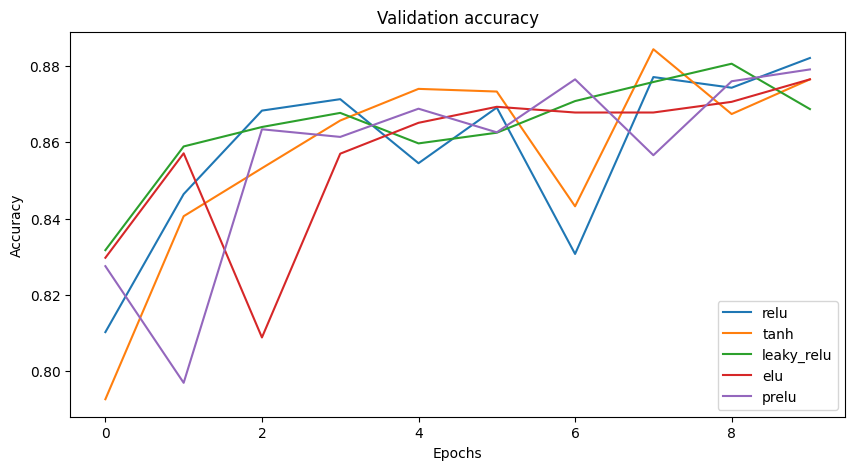

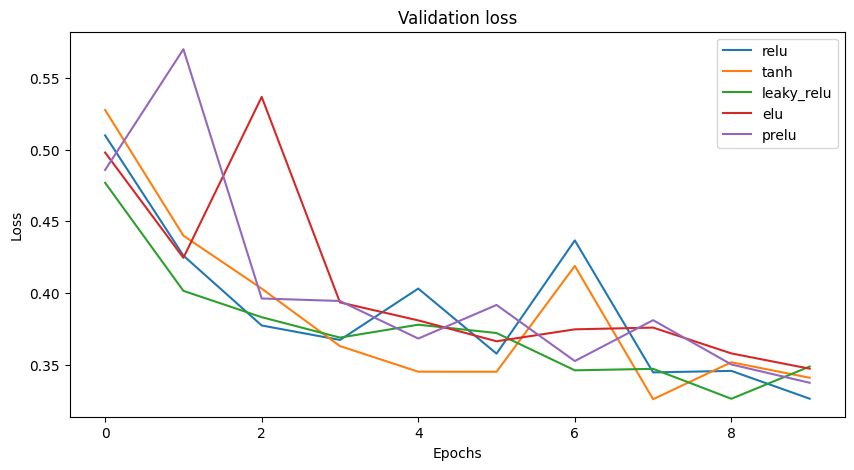


--- ПОРІВНЯЛЬНА ТАБЛИЦЯ ---
   Activation  Train Time (s)  Inference Time (s)  Final Acc
0        relu       34.981462            0.128615     0.8821
1        tanh       62.834762            0.211305     0.8765
2  leaky_relu       43.399204            0.120428     0.8687
3         elu       42.709906            0.116487     0.8765
4       prelu       40.584368            0.098132     0.8791


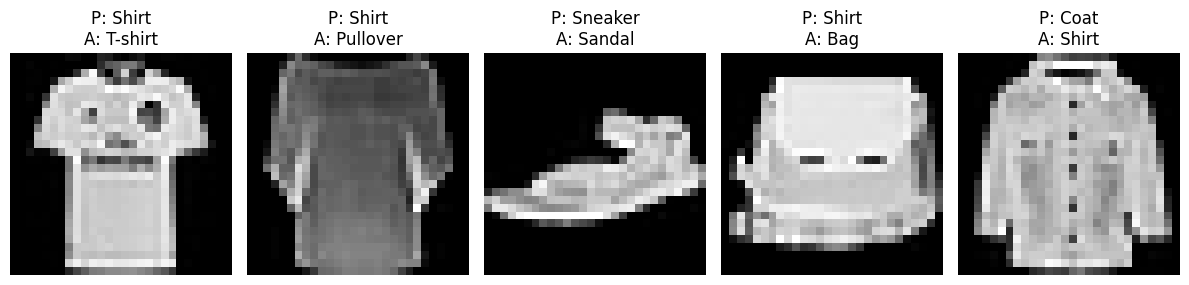

In [29]:
# ==========================================
#  PLOTS
# ==========================================

# Task point 9
plt.figure(figsize=(10, 5))
for act in results:
    plt.plot(results[act]['history']['val_acc'],label=act)
plt.title("Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))

for act in results:
    plt.plot(results[act]['history']['val_loss'],label=act)

plt.title("Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# TABLE COMPARISON (Task point 11)
data = []
for act in results:
    r = results[act]
    data.append([act, r['train_time'], r['inf_time'], r['history']['val_acc'][-1]])

df_comp = pd.DataFrame(data, columns=['Activation', 'Train Time (s)', 'Inference Time (s)', 'Final Acc'])
print("\n--- ПОРІВНЯЛЬНА ТАБЛИЦЯ ---")
print(df_comp)

# Plot Mistakes (Task point 12)
best_act = 'relu' # або будь-яка інша
m = results[best_act]['model']
preds = np.argmax(m.forward(X_test), axis=1)
actual = y_test_raw
errors = np.where(preds != actual)[0]

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(12, 5))
for i, idx in enumerate(errors[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"P: {class_names[preds[idx]]}\nA: {class_names[actual[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()